In [174]:
from urllib.request import urlretrieve
url = 'https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt'
filename = r'c:\users\alfac\desktop\unimib\corso_astrostat\summary_table.txt'
# urlretrieve(url, filename)

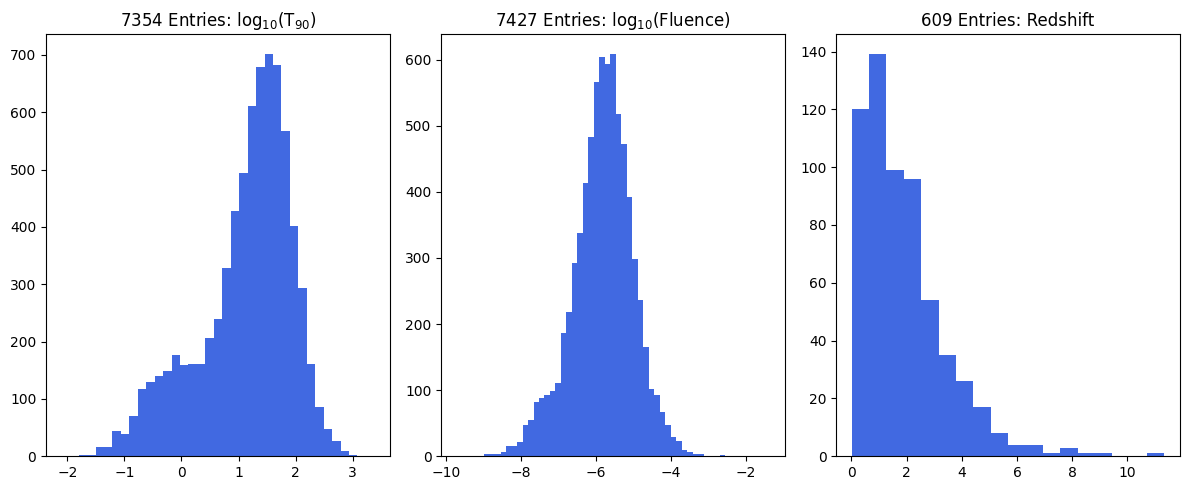

In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
# Read content
data = np.loadtxt("../../summary_table.txt", dtype='str', unpack='True')
# Read headers
with open("../../summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

types = np.array(['str', 'str', 'str', 'float', 'float', 'float', 'float', 'float', 'str', 'float', 'float', 'float', 'float', 'bool', 'float'])
# data = data.T

data = pd.DataFrame(data.T, columns=names, dtype='str')
### Separating the string and boolean data from the floats.
data_str    = data[names[(types =='str'  )]]; # print(data_str.columns)
data_bool   = data[names[(types =='bool' )]]; # print(data_bool.columns)
data        = pd.DataFrame( data[names[(types =='float')]], dtype=float )

tMask   = [ t > 0 for t in data['T90']]
T90     = np.log10( data['T90'].to_numpy()[tMask] )
tBins   = np.linspace(min(T90), max(T90), 100)
T90_err = data['T90_error'].to_numpy()[tMask]

fMask       = [ f > 0 for f in data['fluence']]
Fluence     = np.log10( data['fluence'].to_numpy()[fMask] )
fBins       = np.linspace(min(Fluence), max(Fluence), 100)
Fluence_err = data['fluence_error'].to_numpy()[fMask]

zMask    = [ z > 0 for z in data['redshift'] ]
Redshift = data['redshift'].iloc[zMask]
zBins    = np.linspace(min(Redshift), max(Redshift), 100)

fig, axs = plt.subplots(1,3, tight_layout=True, figsize=(12,5))
from astropy.visualization import hist
values, _, _ = hist(T90     , facecolor='royalblue', bins='scott', ax=axs[0])
_ = axs[0].set_title(str(int(sum(values))) + r' Entries: log$_{10}($T$_{90})$')
values, _, _ = hist(Fluence , facecolor='royalblue', bins='scott', ax=axs[1])
_ = axs[1].set_title(str(int(sum(values))) + r' Entries: log$_{10}($Fluence$)$')
values, _, _ = hist(Redshift, facecolor='royalblue', bins='scott', ax=axs[2])
_ = axs[2].set_title(str(int(sum(values))) + r' Entries: Redshift')

First considerations: the number of entries in the Redshift histogram is significantly lower. It is in fact hard to measure it, for a GRB!

I will therefore focus on the Fluence and T90, to then examine the redshift.

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed?

I am aware of the existence of two GRB populations. I would like to check whether the histograms of the log(Fluence) and log(T$_{90}$}) are correlated and/or overlapping. Let's check if I can get to similar conclusions on the two datasets.

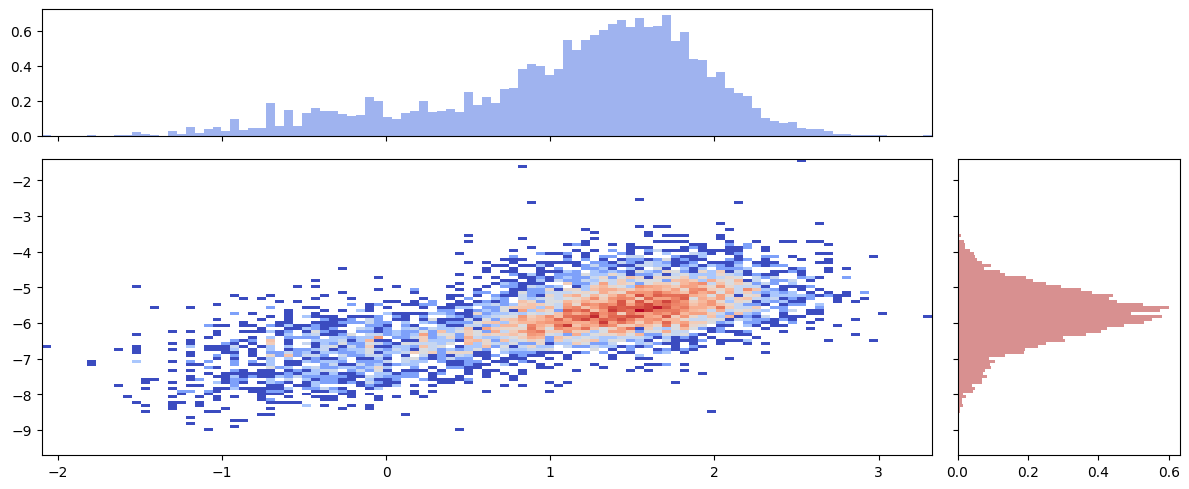

In [176]:
df = data.iloc[np.logical_and(fMask, tMask)] ### Selecting only compatible data (nValues < nTot)
x  = np.log10(df['T90'])
y  = np.log10(df['fluence'])
fig, axs = plt.subplots(2,2, tight_layout=True, sharex='col', sharey='row', figsize=(12,5), 
                        width_ratios=[0.8, 0.2], height_ratios=[0.3, 0.7])
# plt.figure(figsize=(12,5), tight_layout=True)
from matplotlib.colors import LogNorm
_ = axs[0,0].hist(x, bins=tBins, alpha=0.5, facecolor='royalblue', density=True)
_ = axs[0,1].remove()
values, _, _, im = axs[1,0].hist2d(x, y, bins=(tBins, fBins), cmap='coolwarm', norm=LogNorm()); #plt.colorbar()
#fig.colorbar(im, ax=axs[0,1]) #values, ax=axs[1][0])
_ = axs[1,1].hist(y, bins=fBins, orientation='horizontal', alpha=0.5, facecolor='firebrick', density=True)
#plt.scatter(x, y, cmap='coolwarm', c=df['redshift'], s=1, vmin=0, vmax=max(df['redshift']))

"By eye", it seems that there are two peaks that may be originating from two gaussians in each 1D histogram, while two "clumps" are clearly visible in the 2D distribution. Let's take sklearn and put it to good use!

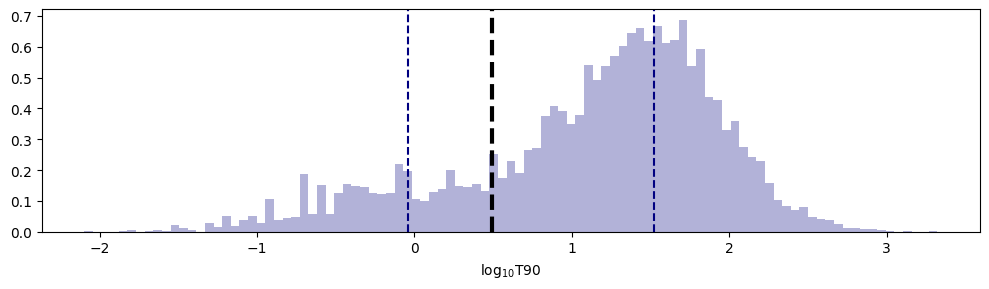

In [177]:
fig, axs = plt.subplots(figsize=(10, 3), tight_layout=True)
hist_data = axs.hist(T90, bins=tBins, density=True, facecolor='navy', alpha=0.3)
axs.set_xlabel(r'log$_{10}$T90')
values, edges = hist_data[0], hist_data[1]
centers = ( edges[1:] + edges[:-1] )*0.5

x = np.linspace(min(T90), max(T90), 1000)

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split as TTS
Xtrain, Xtest, _, _, = TTS(T90, [None for _ in range(len(T90))], test_size=0.2, train_size=0.8)

model = KMeans(n_clusters=2)
model.fit(X=np.array(Xtrain).reshape(-1,1))
for line in model.cluster_centers_: axs.axvline(line, zorder=1, lw=1.5, ls='--', c='navy')
split = model.predict(x.reshape(-1,1)) #### labels = [1,1,1....,0,0,0,....]
iSplit = len(split[split==1])          #### hence I do this to plot the axvline
axs.axvline(x[ iSplit ], lw=3, ls='--', c='k', zorder=1) 

As far as the T90 is concerned, it seems that I get the ~2s separation (black line) and the two cluster centers are "in the right place". Given that we know of two populations of GRBs, I feel safe and **fix** the n_cluster=2 "hyperparameter".

Let's move on to the GRB fluence and see what happens there. This time, I compare the clustering from KMeans with a GaussianMixture.

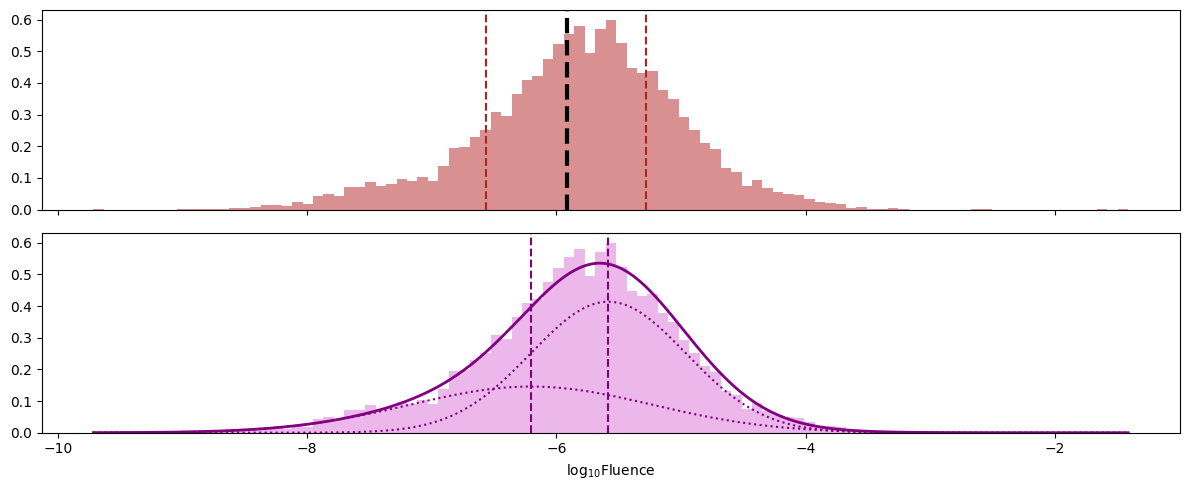

In [186]:
np.random.seed(314159)
fig, axs = plt.subplots(2,1, figsize=(12, 5), tight_layout=True, sharex=True, sharey=True)
hist_data = axs[0].hist(Fluence, bins=fBins, density=True, facecolor='firebrick', alpha=0.5)
axs[1].set_xlabel(r'log$_{10}$Fluence')
values, edges = hist_data[0], hist_data[1]
centers = ( edges[1:] + edges[:-1] )*0.5

x = np.linspace(min(Fluence), max(Fluence), 1000)

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split as TTS
Xtrain, Xtest, _, _, = TTS(Fluence, [None for _ in range(len(Fluence))], test_size=0.2, train_size=0.8)

model1 = KMeans(n_clusters=2)
model1.fit(X=np.array(Xtrain).reshape(-1,1))
for line in model1.cluster_centers_: 
    axs[0].axvline(line, zorder=1, lw=1.5, ls='--', c='firebrick')
split = model1.predict(x.reshape(-1,1)) #### labels = [1,1,1....,0,0,0,....]
iSplit = len(split[split==1])           #### hence I do this to plot the axvline
axs[0].axvline(x[ iSplit ], lw=3, ls='--', c='k', zorder=1) 

from sklearn.mixture import GaussianMixture
model2 = GaussianMixture(n_components=2)
model2.fit(X=np.array(Xtrain).reshape(-1,1))
from scipy.stats import norm

axs[1].hist(Fluence, bins=fBins, density=True, facecolor='orchid', alpha=0.5)
yTot = np.zeros(len(x))
for mu, cov, weight in zip(model2.means_, model2.covariances_.flatten(), model2.weights_):
    sigma = cov**0.5
    axs[1].axvline(mu, zorder=1, lw=1.5, ls='--', c='purple')
    axs[1].plot(x, weight*norm.pdf(x, loc=mu, scale=sigma), c='purple', ls=':')
    yTot += weight*norm.pdf(x, loc=mu, scale=sigma)

axs[1].plot(x, yTot, c='purple', ls='-', lw=2) 

It doesn't look like the cluster centroids predicted by KMeans (red lines) are in the right place. Also, the separation between the two look very un-natural.

The GaussianMixture method provides a much better "fit" of the model, although it seems like it's missing the peak of the distribution. Also, the gaussian means are MUCH closer to each other!

Let's try this again, this time in 2D.

- First plot: comparing the performance of two related methods: KMeans and BisectingKMeans

Do similar clustering methods yield different results?
nTest = Same Label + Different Label
YES: only very little points are "confused" between distributions.
1448 : 1443 5


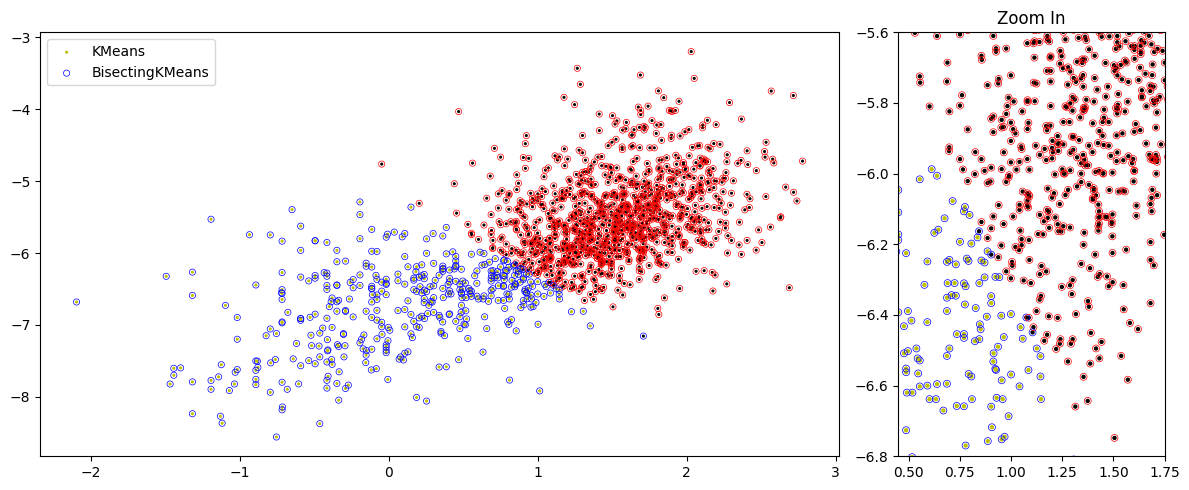

In [166]:
np.random.seed(314159)
fig, axs = plt.subplots(1,2, figsize=(12,5), tight_layout=True, width_ratios=[0.75,0.25])
Xfull = np.vstack( (np.log10(df['T90']), np.log10(df['fluence']) )).T
Xtrain, Xtest, _, _, = TTS(Xfull, [[None, None] for _ in range(np.shape(Xfull)[0])], test_size=0.2, train_size=0.8)
model1 = KMeans(n_clusters=2)
model1.fit(Xtrain)
pColors = model1.predict(Xtest)
 
axs[0].scatter(Xtest[:,0], Xtest[:,1], facecolors=['k' if pC == 0 else 'y' for pC in pColors], s=5,  marker='o', edgecolor=(0,0,0,0), label='KMeans')
axs[1].scatter(Xtest[:,0], Xtest[:,1], facecolors=['k' if pC == 0 else 'y' for pC in pColors], s=10, marker='o', edgecolor=(0,0,0,0), label='KMeans')
from sklearn.cluster import BisectingKMeans
model2 = BisectingKMeans(n_clusters=2)
model2.fit(Xtrain)
pColors = model2.predict(Xtest)

axs[0].scatter(Xtest[:,0], Xtest[:,1], edgecolors=['r' if pC == 0 else 'b' for pC in pColors], s=20, marker='o', lw=0.5, facecolor=(0,0,0,0), label='BisectingKMeans')
axs[1].scatter(Xtest[:,0], Xtest[:,1], edgecolors=['r' if pC == 0 else 'b' for pC in pColors], s=25, marker='o', lw=0.5, facecolor=(0,0,0,0), label='BisectingKMeans')

axs[0].legend()
axs[1].set_title('Zoom In')
axs[1].set_xlim(0.45,1.75); axs[1].set_ylim(-6.8,-5.6)
print('Do similar clustering methods yield different results?')
print('nTest = Same Label + Different Label')
print('YES: only very little points are "confused" between distributions.')

print(len(Xtest), ':', np.count_nonzero(model1.predict(Xtest) == model2.predict(Xtest)), np.count_nonzero(model1.predict(Xtest) != model2.predict(Xtest)))

It seems that the two methods are NOT that different from each other, and that very few points are clustered with different groups. The separation between the two seems to be a straight line, somewhere in the middle. I am not convinced by this result, hence...

- Second Plot: comparing the performance of KMeans with (again) a GaussianMixture method.

Do very different clustering methods yield different results?
nTest = Same Label + Different Label
NO: by eye, one can clearly see some confusion!
1448 : 1361 87


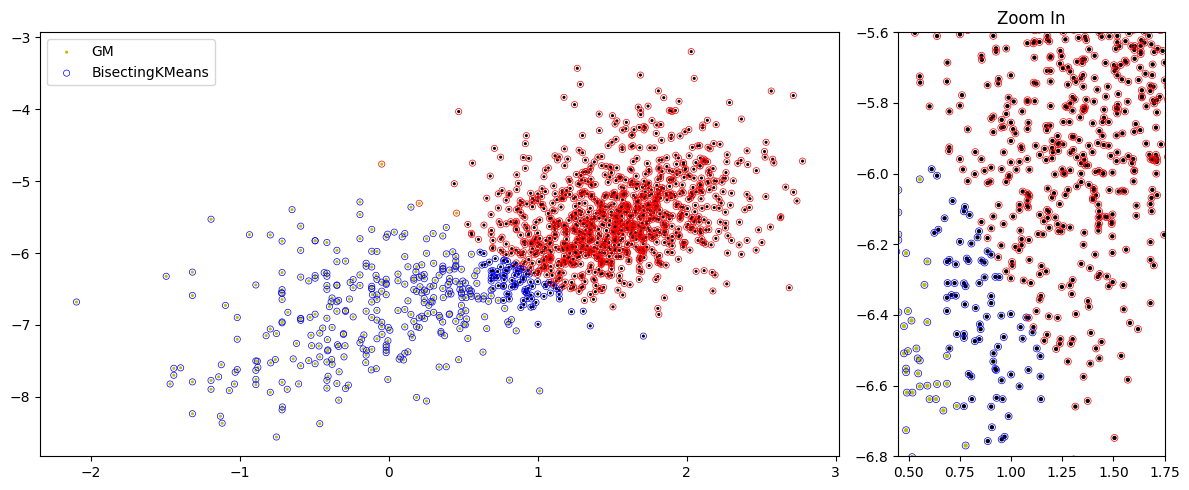

In [167]:
np.random.seed(314159)
from sklearn.mixture import GaussianMixture
fig, axs = plt.subplots(1,2, figsize=(12,5), tight_layout=True, width_ratios=[0.75,0.25])
Xfull = np.vstack( (np.log10(df['T90']), np.log10(df['fluence']) )).T
Xtrain, Xtest, _, _, = TTS(Xfull, [[None, None] for _ in range(np.shape(Xfull)[0])], test_size=0.2, train_size=0.8)
model1 = GaussianMixture(n_components=2)
model1.fit(Xtrain)
pColors = model1.predict(Xtest)
axs[0].scatter(Xtest[:,0], Xtest[:,1], facecolors=['k' if pC == 0 else 'y' for pC in pColors], s=5,  marker='o', edgecolor=(0,0,0,0), label='GM')
axs[1].scatter(Xtest[:,0], Xtest[:,1], facecolors=['k' if pC == 0 else 'y' for pC in pColors], s=10, marker='o', edgecolor=(0,0,0,0), label='GM')

model2 = KMeans(n_clusters=2)
model2.fit(Xtrain)
pColors = model2.predict(Xtest)

axs[0].scatter(Xtest[:,0], Xtest[:,1], edgecolors=['r' if pC == 0 else 'b' for pC in pColors], s=20, marker='o', lw=0.5, facecolor=(0,0,0,0), label='BisectingKMeans')
axs[1].scatter(Xtest[:,0], Xtest[:,1], edgecolors=['r' if pC == 0 else 'b' for pC in pColors], s=25, marker='o', lw=0.5, facecolor=(0,0,0,0), label='BisectingKMeans')

axs[0].legend()
axs[1].set_title('Zoom In')
axs[1].set_xlim(0.45,1.75); axs[1].set_ylim(-6.8,-5.6)
print('Do very different clustering methods yield different results?')
print('nTest = Same Label + Different Label')
print('NO: by eye, one can clearly see some confusion!')
print(len(Xtest), ':', np.count_nonzero(model1.predict(Xtest) == model2.predict(Xtest)), np.count_nonzero(model1.predict(Xtest) != model2.predict(Xtest)))

THIS time, it looks like the two algorithms produce different results. In this plot, I select two colors, which correspond to the method labels. The 'dot' markers and colors correspond to the GaussianMixture outcome on Xtest, while the empty circles show the previous KMeans predictions.

- Whenever I get a blue circle AND a black dot, it means that the two algorithms make different predictions for that point (zoom-in on the right).
- Similarly, whenever I get a red circle AND a green dot, the opposite labels are not matching (say, 0-1 instead of 1-0).

This time, the separation sits in a different region, and the "disagreement" involves a lot more points!

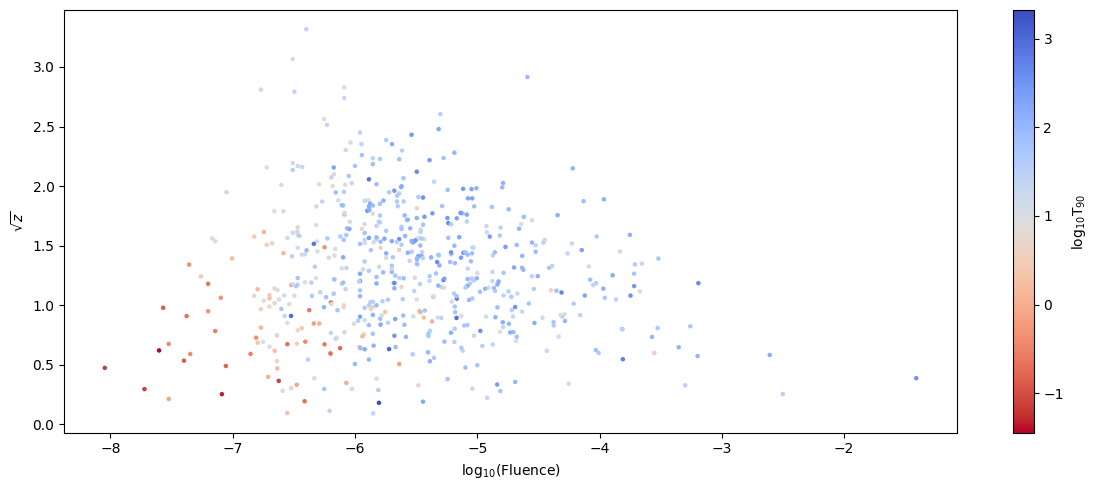

In [168]:
df = data.iloc[np.logical_and(fMask, np.logical_and(zMask, tMask))]
Fluence = np.log10(df['fluence'])
T90     = np.log10(df['T90'])
Redshift= df['redshift']

zBins = np.linspace(min(Redshift), max(Redshift), 100)
import matplotlib.colors as mcolors
from matplotlib import cm
cmap = cm.get_cmap('coolwarm_r')
norm = mcolors.Normalize(vmin=min(T90), vmax=max(T90))

zBins = np.append(zBins, max(zBins)+np.diff(zBins)[0]) ### Adding one extra z+delta(z)
plt.figure(figsize=(12,5), tight_layout=True)
plt.scatter(Fluence, np.sqrt(Redshift), c=T90, cmap='coolwarm_r', s=5); plt.colorbar(label=r'log$_{10}$T$_{90}$')
dBin = 20
for i in range(0, len(zBins)-dBin, dBin):
    mask = np.logical_and( (Redshift < zBins[i+dBin]), (Redshift >= zBins[i]))
    tLevel = np.median(T90[mask]) # The "color" matches the log(Fluence)
    color = cmap(norm(tLevel))        # More intense fluence, more blue; red otherwise.
    #plt.axhspan(ymin=np.sqrt(zBins[i]), ymax=np.sqrt(zBins[i+dBin]), facecolor=color, alpha=0.2)
    #plt.axhline(np.sqrt(zBins[i]), c='gray', ls='--', lw=1, alpha=0.5)
    #plt.axhline(np.sqrt(zBins[i+dBin]), c='gray', ls='--', lw=1, alpha=0.5)

plt.ylabel(r'$\sqrt{z}$')
plt.xlabel(r'log$_{10}$(Fluence)')
zBins = zBins[:-1] # dropping the extra guy

Once again: by eye, it seems that the events with the lowest T90 are also clumped at low redshift AND low fluence. As far as the redshift aspect is concerned:

1) as I previously mentioned, there are very few objects whose z has successfully been measured ( ~600 events in the ~8000 elements of the catalogue )
2) moreover, selection effects may be affecting the detection of these events. In fact, as far as the high-T90 population is concerned (blue dots), several more data points are populating the plot at higher redshifts. The same can NOT be said about short GRBs (red dots), which are only limited to z~1.5.

---

Was it ok to neglect the errors in this analysis? Let's check whether it is ok!

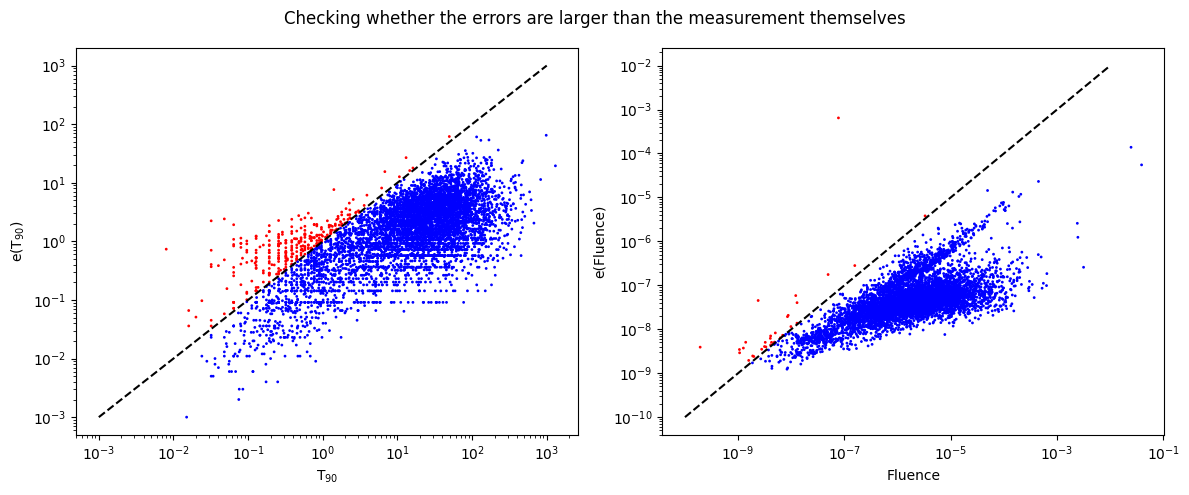

In [169]:
T90 = data['T90'].to_numpy()
eT90= data['T90_error'].to_numpy()
tMask = [ t > 0 for t in T90 ]
eMask = [ e > 0 for e in eT90]
mask  = np.logical_and(tMask, eMask)
eT90  = eT90[mask]
T90   = T90[mask]
fig, axs = plt.subplots(1, 2, figsize=(12,5), tight_layout=True)
axs[0].scatter(x=T90, y=eT90, s=1, c=['r' if t < e else 'b' for e,t in zip(eT90, T90)])
axs[0].plot([1e-3, 1e3], [1e-3, 1e3], c='k', ls='--')
axs[0].loglog()
axs[0].set_xlabel(r'T$_{90}$')
axs[0].set_ylabel(r'e(T$_{90}$)')

Fluence = data['fluence'].to_numpy()
eFluence= data['fluence_error'].to_numpy()
fMask = [ f > 0 for f in Fluence ]
eMask = [ e > 0 for e in eFluence]
mask  = np.logical_and(fMask, eMask)
eFluence = eFluence[mask]
Fluence  =  Fluence[mask]

axs[1].scatter(x=Fluence, y=eFluence, s=1, c=['r' if f < e else 'b' for e,f in zip(eFluence, Fluence)])
axs[1].plot([1e-10, 1e-2], [1e-10, 1e-2], c='k', ls='--')
axs[1].loglog()
axs[1].set_xlabel(r'Fluence')
axs[1].set_ylabel(r'e(Fluence)')

_ = fig.suptitle('Checking whether the errors are larger than the measurement themselves')

As far as the T90 is concerned, there is a quite significant portion of measurements that carries a large relative uncertainty. The fact that this is affecting the short-GRB regime most of the time may be be explained with the brief duration of the transient itself!


On the other hand, in the case of the GRB fluence, the measurement error is lower and well constrained, most of the time.

0.038836


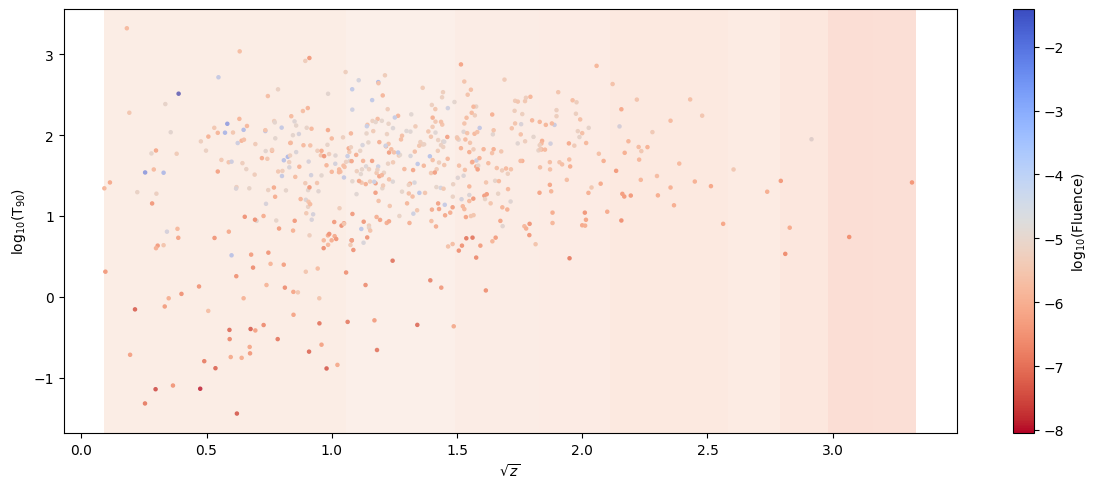

In [170]:
import matplotlib.colors as mcolors
from matplotlib import cm

df2 = data.iloc[np.logical_and(tMask, np.logical_and(fMask, zMask))]
cmap = cm.get_cmap('coolwarm_r')
norm = mcolors.Normalize(vmin=min(np.log10(df2['fluence'])), vmax=max(np.log10(df2['fluence'])))


zBins = np.linspace(min(df2['redshift']), max(df2['redshift']), 100)
zBins = np.append(zBins, max(zBins)+np.diff(zBins)[0]) ### Adding one extra z+delta(z)

plt.figure(figsize=(12,5), tight_layout=True)
#mask = np.logical_and(tMask, fMask)
print(max(df2['fluence']))
plt.scatter(np.sqrt(df2['redshift']), np.log10(df2['T90']), s=5, c=np.log10(df2['fluence']), cmap='coolwarm_r')
plt.colorbar(label=r'log$_{10}$(Fluence)')
plt.xlabel(r'$\sqrt{z}$')
plt.ylabel(r'log$_{10}($T$_{90})$')
dBin = 10
for i in range(0, len(zBins)-dBin, dBin):
    mask = np.logical_and( ( df2['redshift'] < zBins[i+dBin] ) , ( df2['redshift'] >= zBins[i] ) )
    #if np.count_nonzero(mask) > 0: 
    c = cmap(norm(np.mean(np.log10(df2['fluence'])[mask])))
    plt.axvspan(xmin=np.sqrt(zBins[i]), xmax=np.sqrt(zBins[i+dBin]), facecolor=c, alpha=0.3)

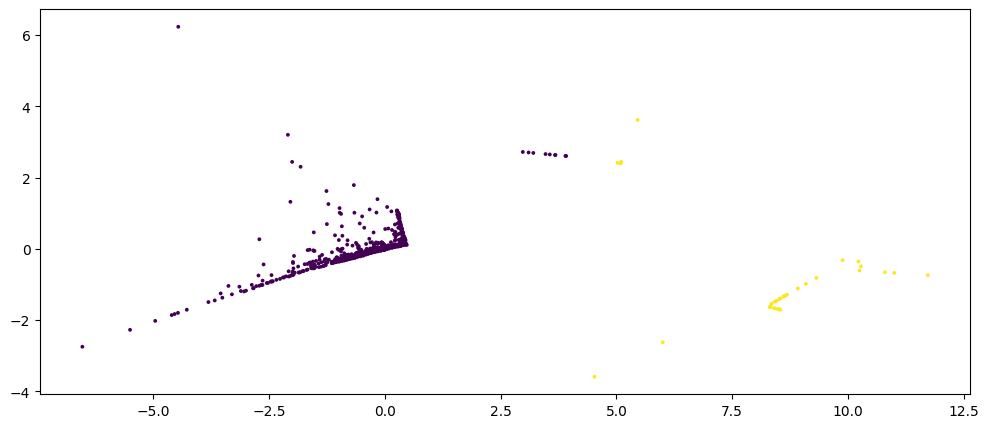

In [171]:
from sklearn.manifold import Isomap
embedding = Isomap(n_components=2)
X = np.array(data[['T90', 'fluence', 'redshift']].iloc[tMask and fMask and zMask].to_numpy())
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
Scaler = StandardScaler()
X = Scaler.fit_transform(X)
X_transformed = embedding.fit_transform(X)
plt.figure(figsize=(12,5))
# plt.scatter(X_transformed[:,0], X_transformed[:,1], s=1)
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2)
model.fit(X_transformed)
model.predict(X_transformed)
plt.scatter(X_transformed[:,0], X_transformed[:,1], s=3, c=model.predict(X_transformed))